##  Monty Hall Problem

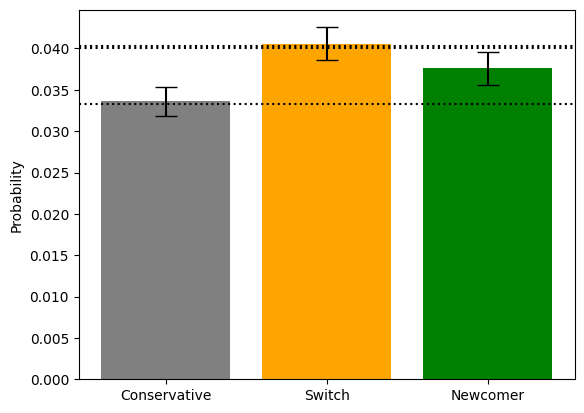

In [37]:
import numpy as np 
import matplotlib.pyplot as plt 
import random

k=10000          #number of experiments 
N=30               #number of doors
P=5             #number of opened doors by the presenter

if N<P+2:
    print("The number of doors must be greater than the number of opened doors plus two.")


switcher=0
conservative=0
newcomer=0

for i in range(k):
        x = np.arange(N)

        prize_pos=np.random.randint(0,N)      #prize position  

        choice1=np.random.randint(0,N)        #first choice 

        deleted1=list(set([prize_pos, choice1])) #array with the prize and the first choice
        y=np.delete(x,deleted1) 
        choicep=random.sample(list(y),P)           #choice of the presenter 
    
        deleted2=np.append(choice1,choicep) 
        z=np.delete(x,deleted2) 
        choice2=np.random.choice(z) 

        w=np.delete(x,choicep) 
        choice3=np.random.choice(w) 
        

        if prize_pos==choice1:
            conservative+=1
        if prize_pos==choice2:
            switcher+=1
        if prize_pos==choice3:
            newcomer+=1

labels = ['Conservative', 'Switch', 'Newcomer']
values = [conservative / k, switcher / k, newcomer / k]
probs = [1/N,(N-1)/(N*(N-P-1)),1/(N-P)]
errors = [np.sqrt(p * (1 - p) / k) for p in probs] #binomial error

plt.bar(labels, values, yerr=errors, capsize=8, color=['gray', 'orange', 'green'])




plt.ylabel("Probability")
#plt.ylim(0, 1)
for y in probs:
    plt.axhline(y, ls='dotted',c='black')

plt.show()
